In [1]:
# ---- SETUP: load data and rebuild our models so this notebook runs on its own ----

# Import everything we need
import pandas as pd                                      # pandas: for our data table
import numpy as np                                       # numpy: for math
import sqlite3                                           # sqlite3: to read our database
import matplotlib.pyplot as plt                          # matplotlib: for drawing charts
from sklearn.model_selection import train_test_split     # to split data into train/test
from sklearn.linear_model import LogisticRegression      # our baseline model
from xgboost import XGBClassifier                        # our stronger model

# Open the database and load the feature table we built in Phase 2
conn = sqlite3.connect(r'C:\Users\User\Desktop\football-xg-model\data\football_xg.db')
df = pd.read_sql("SELECT * FROM shot_features", conn)    # load all 9168 shots with features

# Separate features (X = the clues) from target (y = the answer: goal or not)
X = df[['distance', 'angle', 'is_header', 'is_penalty', 'is_open_play']]
y = df['goal']

# Split into the SAME train/test piles as before (same random_state = identical split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Rebuild and train the baseline (logistic regression)
baseline_model = LogisticRegression(max_iter=1000)       # create it
baseline_model.fit(X_train, y_train)                     # train it on the training pile

# Rebuild and train XGBoost
xgb_model = XGBClassifier(n_estimators=200, max_depth=4,
                          learning_rate=0.05, eval_metric='logloss',
                          random_state=42)                # create it with same settings
xgb_model.fit(X_train, y_train)                          # train it

# Get each model's predicted xG on the hidden test shots
baseline_preds = baseline_model.predict_proba(X_test)[:, 1]   # baseline's xG predictions
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]             # XGBoost's xG predictions

# Also grab StatsBomb's xG for the same test shots (our benchmark)
statsbomb_preds = df.loc[X_test.index, 'shot_statsbomb_xg']

# Confirm setup is done
print("Setup complete — models trained and predictions ready.")
print("Test shots:", len(y_test))

Setup complete — models trained and predictions ready.
Test shots: 1834


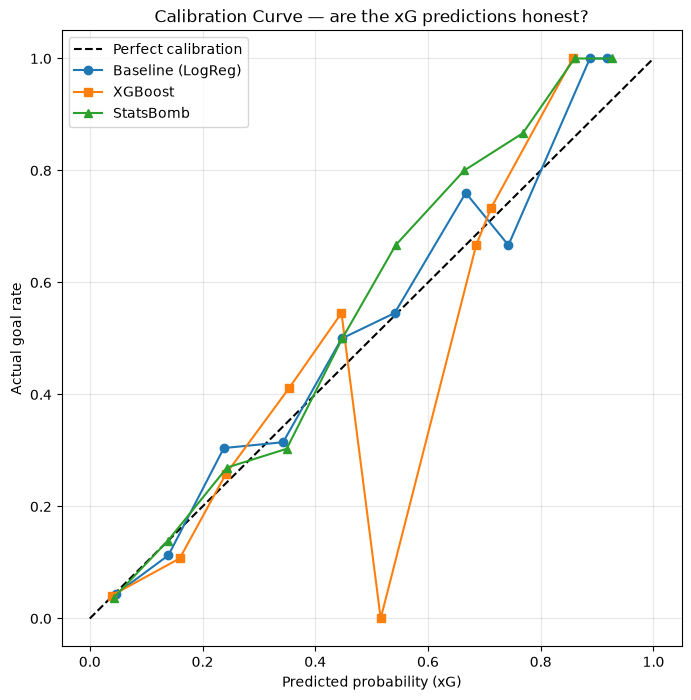

In [2]:
# Import the tool that calculates calibration points for us
from sklearn.calibration import calibration_curve

# ---- Calculate calibration for each model ----
# calibration_curve groups shots into bins by predicted probability, then finds:
#   prob_true  = the ACTUAL goal rate in each bin
#   prob_pred  = the AVERAGE predicted xG in each bin
# n_bins=10 splits predictions into 10 groups (0-10%, 10-20%, etc.)

# Baseline model calibration
base_true, base_pred = calibration_curve(y_test, baseline_preds, n_bins=10)

# XGBoost calibration
xgb_true, xgb_pred = calibration_curve(y_test, xgb_preds, n_bins=10)

# StatsBomb calibration (our benchmark)
sb_true, sb_pred = calibration_curve(y_test, statsbomb_preds, n_bins=10)

# ---- Draw the chart ----
plt.figure(figsize=(8, 8))                               # make a square 8x8 figure

# The "perfect calibration" line: a diagonal from (0,0) to (1,1)
# If a model's dots sit on this line, its probabilities are perfectly honest.
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')  # 'k--' = black dashed line

# Plot each model's calibration curve (predicted on x-axis, actual on y-axis)
plt.plot(base_pred, base_true, 'o-', label='Baseline (LogReg)')   # blue dots+line
plt.plot(xgb_pred, xgb_true, 's-', label='XGBoost')              # squares
plt.plot(sb_pred, sb_true, '^-', label='StatsBomb')             # triangles

# Label the axes and add a title so the chart is readable
plt.xlabel('Predicted probability (xG)')                 # x-axis: what the model predicted
plt.ylabel('Actual goal rate')                           # y-axis: what really happened
plt.title('Calibration Curve — are the xG predictions honest?')
plt.legend()                                             # show the labels for each line
plt.grid(True, alpha=0.3)                                # faint grid for readability

# Display the chart
plt.show()

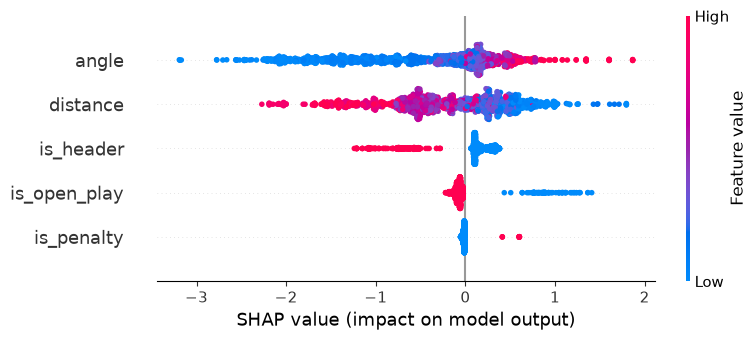

In [3]:
# Import the SHAP library — it explains WHY a model makes each prediction
import shap                                              # the interpretability tool

# Create a SHAP "explainer" for our XGBoost model.
# TreeExplainer is the fast, exact version made specifically for tree models like XGBoost.
explainer = shap.TreeExplainer(xgb_model)                # set up the explainer on our trained model

# Calculate SHAP values for the test shots.
# SHAP values tell us how much EACH feature pushed EACH prediction up or down.
shap_values = explainer.shap_values(X_test)              # compute the explanations

# ---- SUMMARY PLOT: which features matter most overall ----
# This chart ranks features by how much they influence predictions.
# Each dot is one shot; colour = the feature's value (red = high, blue = low);
# position = how much it pushed the xG prediction up (right) or down (left).
shap.summary_plot(shap_values, X_test)                   # draw the SHAP summary chart

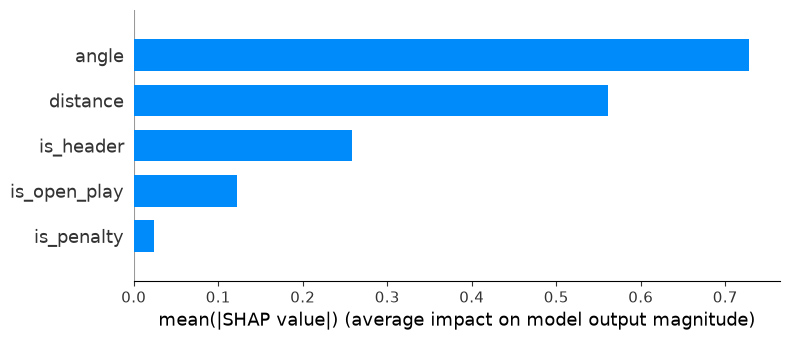

In [4]:
# ---- FEATURE IMPORTANCE BAR CHART ----
# SHAP can also give a simple "bar" version: the average impact of each feature.
# This is easier to read at a glance than the dot plot — one bar per feature.

# plot_type="bar" tells SHAP to draw the simple bar version instead of the dot swarm.
# It averages how much each feature affects predictions (bigger bar = more important).
shap.summary_plot(shap_values, X_test, plot_type="bar")

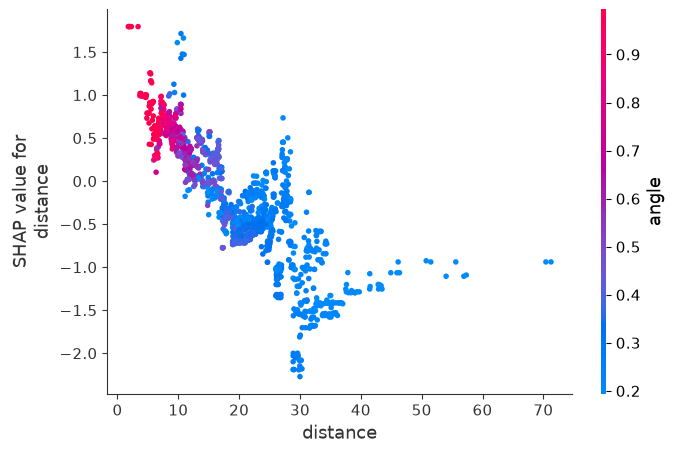

In [5]:
# ---- DEPENDENCE PLOT: how does DISTANCE affect xG across its full range? ----
# This shows, for every value of distance, how much it pushed the prediction up or down.
# It reveals the SHAPE of the relationship (is it a straight line? a curve?).
# x-axis = distance value, y-axis = how much that distance changed the xG prediction.
shap.dependence_plot("distance", shap_values, X_test)

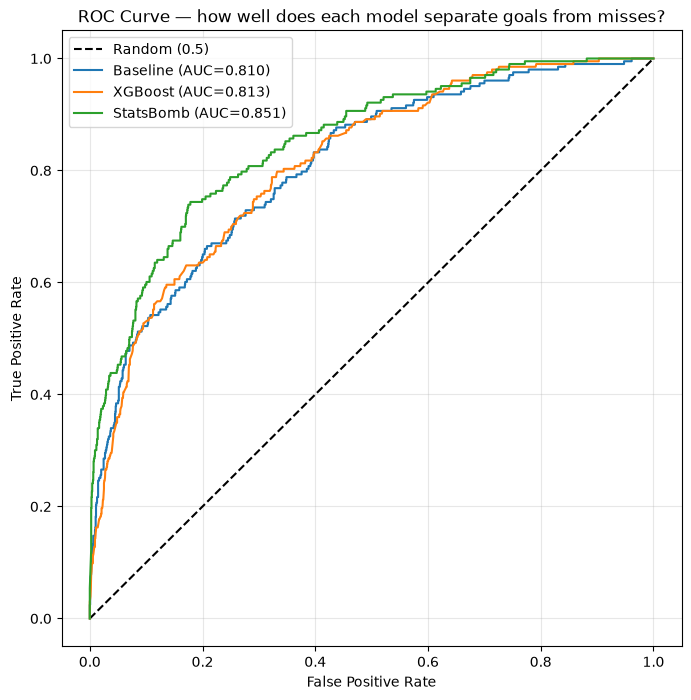

In [6]:
# ---- ROC CURVE: a classic visual of how well the model separates goals from non-goals ----
from sklearn.metrics import roc_curve, roc_auc_score   # tools to compute the ROC curve

# Compute the ROC curve points for each model.
# roc_curve gives false-positive-rate (fpr) and true-positive-rate (tpr) at every threshold.
base_fpr, base_tpr, _ = roc_curve(y_test, baseline_preds)   # baseline curve points
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_preds)          # xgboost curve points
sb_fpr, sb_tpr, _ = roc_curve(y_test, statsbomb_preds)      # statsbomb curve points

# Draw the chart
plt.figure(figsize=(8, 8))                                  # square figure
plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)')       # diagonal = random guessing

# Plot each model's ROC curve, with its AUC score in the label
plt.plot(base_fpr, base_tpr, label=f'Baseline (AUC={roc_auc_score(y_test, baseline_preds):.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_preds):.3f})')
plt.plot(sb_fpr, sb_tpr, label=f'StatsBomb (AUC={roc_auc_score(y_test, statsbomb_preds):.3f})')

# Labels and title. The higher/left the curve bows, the better the model.
plt.xlabel('False Positive Rate')                           # x-axis
plt.ylabel('True Positive Rate')                            # y-axis
plt.title('ROC Curve — how well does each model separate goals from misses?')
plt.legend()                                                # show model labels + AUCs
plt.grid(True, alpha=0.3)                                   # faint grid
plt.show()

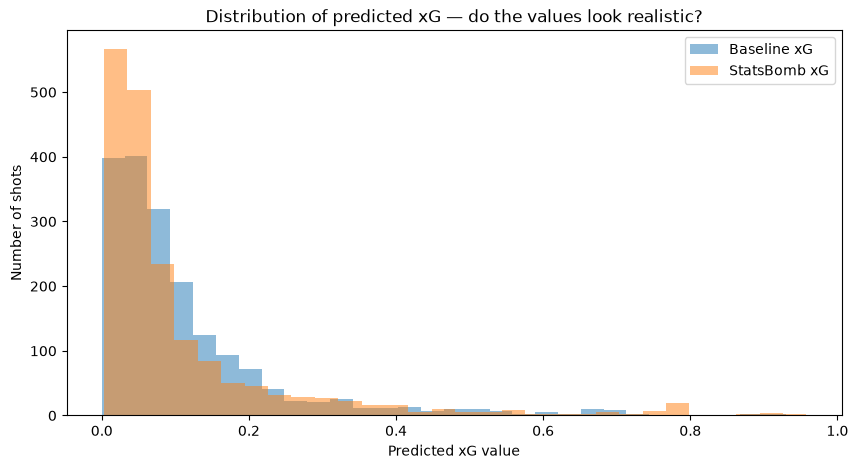

In [7]:
# ---- DISTRIBUTION CHECK: do our predicted xG values look realistic? ----
# A good xG model should predict LOTS of low values (most shots are poor chances)
# and FEW high values. Let's compare our model's spread against StatsBomb's.
plt.figure(figsize=(10, 5))                                 # wide figure

# Draw overlapping histograms of the predicted xG values.
# bins=30 splits the 0-1 range into 30 bars; alpha=0.5 makes them see-through.
plt.hist(baseline_preds, bins=30, alpha=0.5, label='Baseline xG')      # our model
plt.hist(statsbomb_preds, bins=30, alpha=0.5, label='StatsBomb xG')    # benchmark

# Labels and title
plt.xlabel('Predicted xG value')                            # x-axis: the xG value
plt.ylabel('Number of shots')                               # y-axis: how many shots
plt.title('Distribution of predicted xG — do the values look realistic?')
plt.legend()                                                # show which is which
plt.show()